 File "/tmp/ipykernel_55/2603572884.py", line 2
    **By:** Nikhil Raghuwanshi
    ^
SyntaxError: invalid syntax

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ashishjangra27/swiggy-restaurants-dataset/data.json
/kaggle/input/datasets/ashishjangra27/swiggy-restaurants-dataset/swiggy.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries imported!")

libraries imported!


In [4]:
df = pd.read_csv("/kaggle/input/datasets/ashishjangra27/swiggy-restaurants-dataset/swiggy.csv")
print("dataset loaded")
print("shape:", df.shape)

dataset loaded
shape: (148541, 11)


## Step 1 - First Look at the Data

In [5]:
df.head()

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            148541 non-null  int64 
 1   name          148455 non-null  object
 2   city          148541 non-null  object
 3   rating        148455 non-null  object
 4   rating_count  148455 non-null  object
 5   cost          148410 non-null  object
 6   cuisine       148442 non-null  object
 7   lic_no        148312 non-null  object
 8   link          148541 non-null  object
 9   address       148455 non-null  object
 10  menu          148541 non-null  object
dtypes: int64(1), object(10)
memory usage: 12.5+ MB


In [7]:
df.isnull().sum()

id                0
name             86
city              0
rating           86
rating_count     86
cost            131
cuisine          99
lic_no          229
link              0
address          86
menu              0
dtype: int64

## Step 2 - Data Cleaning

Issues I found:
- lic_no column has too many missing values, not useful
- cost column has ₹ symbol, need to remove
- rating column has '--' values
- rating_count has values like 'Too Few Ratings', '1K+ ratings' - not useful
- some missing values in cuisine
- city and name have inconsistent uppercase/lowercase

In [8]:
# dropping columns not needed for analysis
df.drop(columns=["lic_no", "link", "menu"], inplace=True)
print("done")

done


In [9]:
# removing duplicates
df.drop_duplicates(inplace=True)
print("duplicates removed, shape now:", df.shape)

duplicates removed, shape now: (148541, 8)


In [10]:
# dropping rows where name or city is missing
# cant analyze without knowing which restaurant or city it is
df.dropna(subset=["name", "city", "address"], inplace=True)
print("rows dropped, shape now:", df.shape)

rows dropped, shape now: (148455, 8)


In [11]:
# checking cost column before cleaning
df["cost"].head(10)

0    ₹ 200
1    ₹ 200
2    ₹ 100
3    ₹ 250
4    ₹ 250
5    ₹ 200
6    ₹ 150
7    ₹ 100
8    ₹ 100
9    ₹ 200
Name: cost, dtype: object

In [12]:
# cost has rupee symbol, removing it and converting to number
df["cost"] = df["cost"].str.replace("₹", "").str.strip()
df["cost"] = pd.to_numeric(df["cost"], errors="coerce")
df["cost"] = df["cost"].fillna(df["cost"].median())
print("cost cleaned")
print(df["cost"].head())

cost cleaned
0    200.0
1    200.0
2    100.0
3    250.0
4    250.0
Name: cost, dtype: float64


In [13]:
# checking rating before cleaning
df["rating"].head(10)

0     --
1    4.4
2    3.8
3    3.7
4     --
5    3.6
6    4.0
7     --
8    4.2
9     --
Name: rating, dtype: object

In [14]:
# rating has '--' where no rating exists
df["rating"] = df["rating"].str.replace("--", "").str.strip()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating"] = df["rating"].fillna(df["rating"].median())
print("rating cleaned")

rating cleaned


In [15]:
# rating_count has messy values like 'Too Few Ratings', '1K+ ratings'
# cant convert these properly so dropping this column
df.drop(columns=["rating_count"], inplace=True)
print("rating_count column dropped")

rating_count column dropped


In [18]:
# filling missing cuisine with Unknown
df["cuisine"] = df["cuisine"].fillna("Unknown")

In [19]:
# fixing inconsistent case like 'DELHI', 'delhi', 'Delhi'
df["city"] = df["city"].str.title()
df["cuisine"] = df["cuisine"].str.title()
df["name"] = df["name"].str.title()
print("case fixed")

case fixed


In [21]:
# found one restaurant in Hinganghat with cost = 300350, clearly wrong entry
# removing outliers above 99th percentile
q99 = df["cost"].quantile(0.99)
df = df[df["cost"] < q99]
print("outliers removed")
print("final shape:", df.shape)

outliers removed
final shape: (145257, 7)


In [22]:
# final check
df.isnull().sum()

id         0
name       0
city       0
rating     0
cost       0
cuisine    0
address    0
dtype: int64

In [23]:
df.dtypes

id           int64
name        object
city        object
rating     float64
cost       float64
cuisine     object
address     object
dtype: object

## Step 3 - EDA (Exploratory Data Analysis)

### Which cities have the most restaurants?

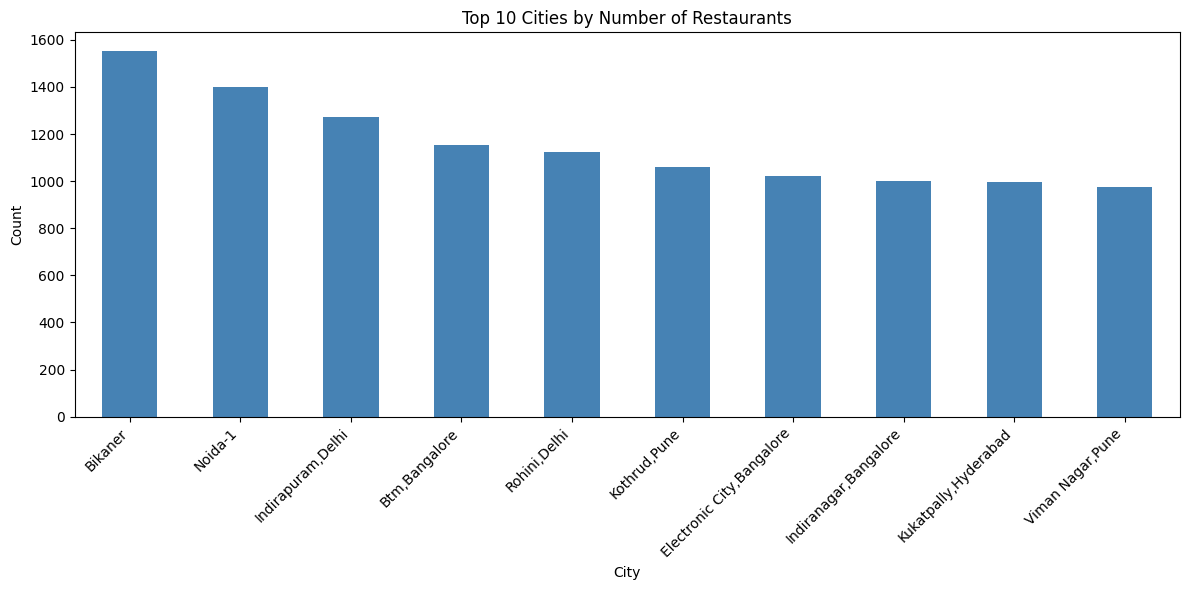

city
Bikaner                      1554
Noida-1                      1400
Indirapuram,Delhi            1271
Btm,Bangalore                1154
Rohini,Delhi                 1122
Kothrud,Pune                 1061
Electronic City,Bangalore    1020
Indiranagar,Bangalore        1002
Kukatpally,Hyderabad          997
Viman Nagar,Pune              974
Name: count, dtype: int64


In [24]:
top_cities = df["city"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_cities.plot(kind="bar", color="steelblue")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(top_cities)

### Most popular cuisines in India

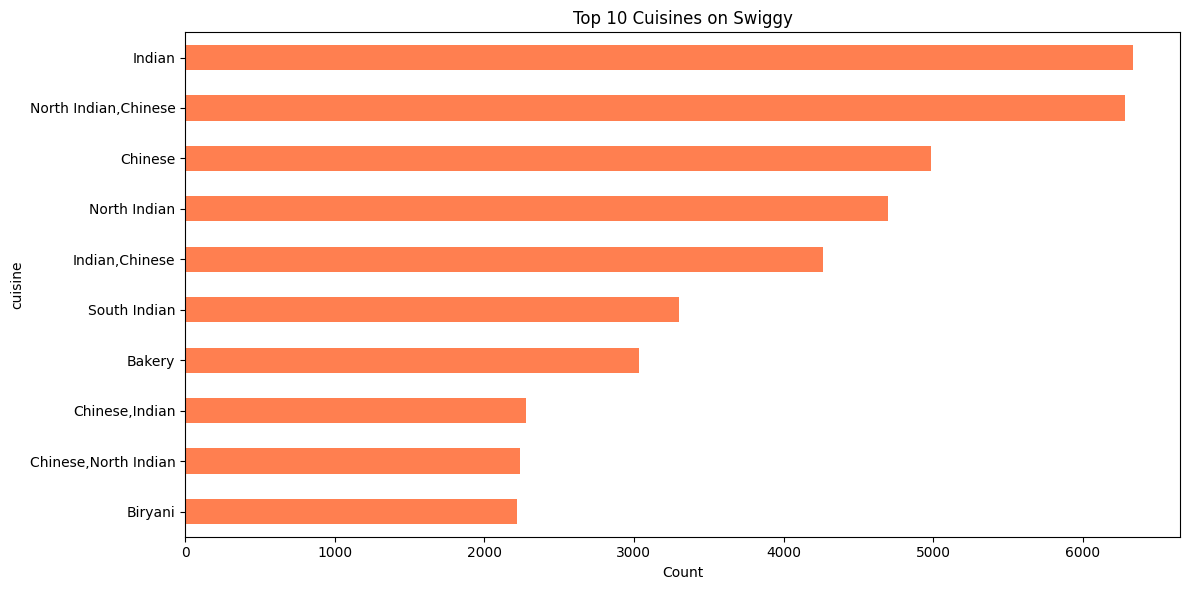

cuisine
Indian                  6333
North Indian,Chinese    6284
Chinese                 4986
North Indian            4698
Indian,Chinese          4262
South Indian            3298
Bakery                  3031
Chinese,Indian          2281
Chinese,North Indian    2236
Biryani                 2219
Name: count, dtype: int64


In [25]:
top_cuisines = df["cuisine"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_cuisines.plot(kind="barh", color="coral")
plt.title("Top 10 Cuisines on Swiggy")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_cuisines)

### Which restaurant chains have the most outlets?

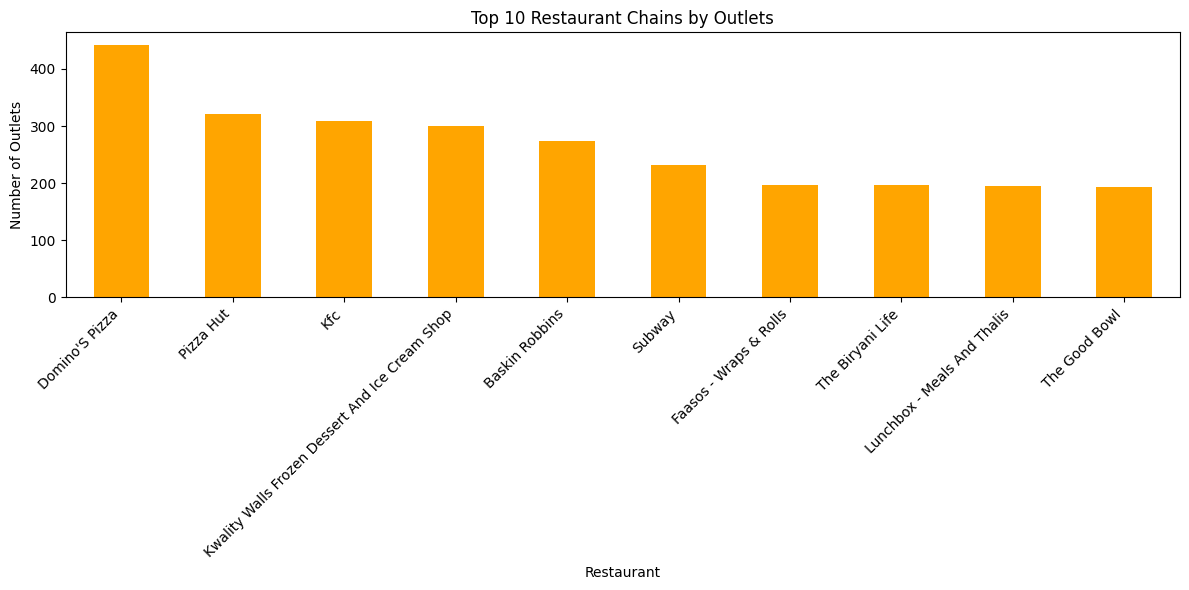

name
Domino'S Pizza                                     442
Pizza Hut                                          321
Kfc                                                309
Kwality Walls Frozen Dessert And Ice Cream Shop    300
Baskin Robbins                                     274
Subway                                             232
Faasos - Wraps & Rolls                             197
The Biryani Life                                   196
Lunchbox - Meals And Thalis                        195
The Good Bowl                                      194
Name: count, dtype: int64


In [28]:
top_chains = df["name"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_chains.plot(kind="bar", color="orange")
plt.title("Top 10 Restaurant Chains by Outlets")
plt.xlabel("Restaurant")
plt.ylabel("Number of Outlets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(top_chains)

### Rating distribution — how are restaurants rated?

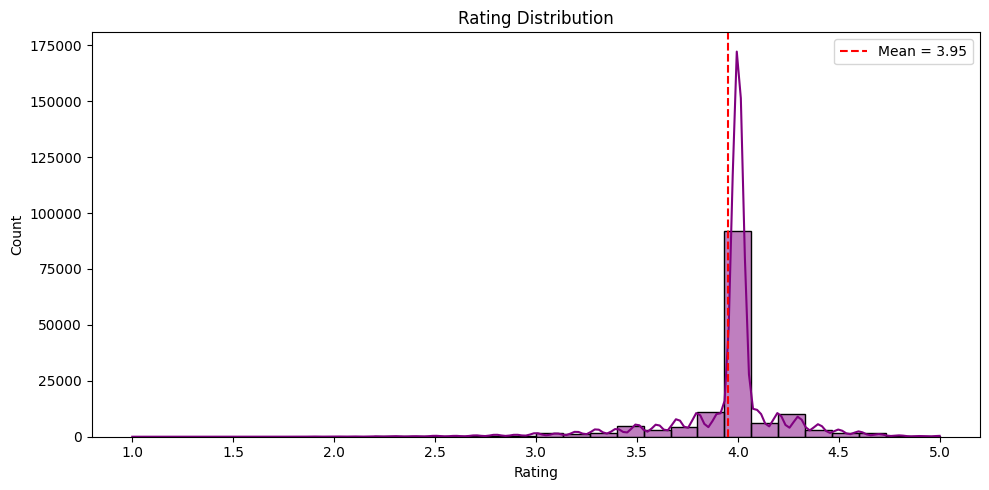

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(df["rating"], bins=30, kde=True, color="purple")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.axvline(df["rating"].mean(), color="red", linestyle="--", label=f'Mean = {df["rating"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

### Which cities have highest average rating?

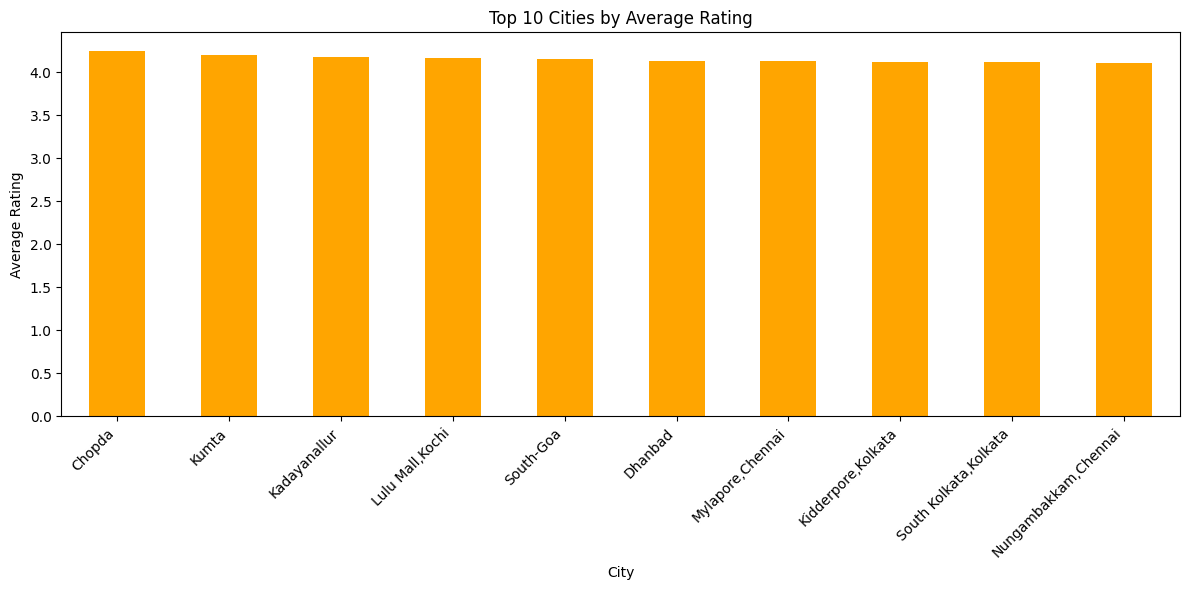

city
Chopda                   4.253846
Kumta                    4.200000
Kadayanallur             4.175000
Lulu Mall,Kochi          4.163636
South-Goa                4.153846
Dhanbad                  4.133333
Mylapore,Chennai         4.133108
Kidderpore,Kolkata       4.125926
South Kolkata,Kolkata    4.119027
Nungambakkam,Chennai     4.112016
Name: rating, dtype: float64


In [30]:
city_rating = df.groupby("city")["rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_rating.plot(kind="bar", color="orange")
plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(city_rating)

### Most expensive cities (avg cost per person)

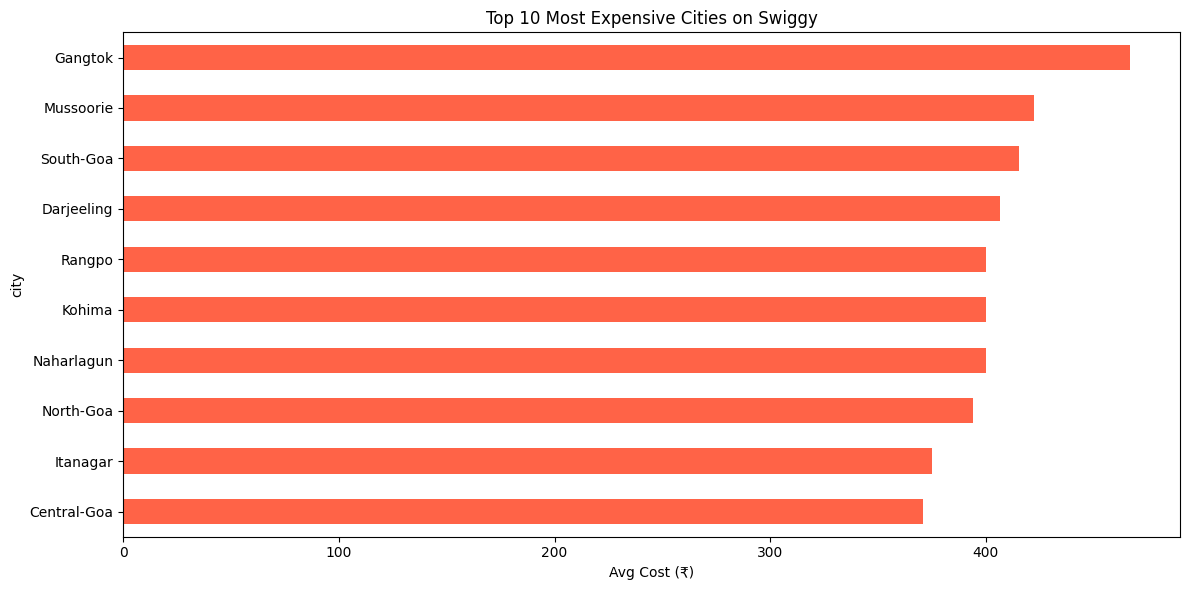

city
Gangtok        466.666667
Mussoorie      422.222222
South-Goa      415.384615
Darjeeling     406.666667
Rangpo         400.000000
Kohima         400.000000
Naharlagun     400.000000
North-Goa      393.942211
Itanagar       375.000000
Central-Goa    370.600536
Name: cost, dtype: float64


In [31]:
city_cost = df.groupby("city")["cost"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_cost.plot(kind="barh", color="tomato")
plt.title("Top 10 Most Expensive Cities on Swiggy")
plt.xlabel("Avg Cost (₹)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(city_cost)

### Does expensive food = better rating?

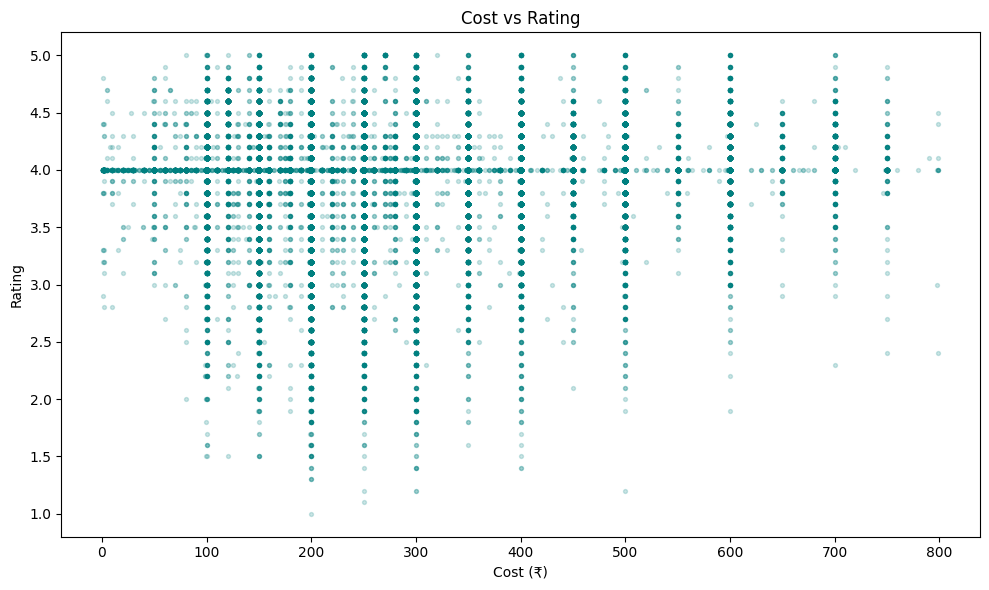

Correlation between cost and rating: 0.0578
Very low correlation — expensive food is not necessarily better rated!


In [32]:
plt.figure(figsize=(10,6))
plt.scatter(df["cost"], df["rating"], alpha=0.2, color="teal", s=8)
plt.title("Cost vs Rating")
plt.xlabel("Cost (₹)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

corr = df["cost"].corr(df["rating"])
print(f"Correlation between cost and rating: {corr:.4f}")
print("Very low correlation — expensive food is not necessarily better rated!")

In [ ]:
# saving cleaned dataset
df.to_csv("swiggy_cleaned.csv", index=False)
print("saved!")
print("final dataset shape:", df.shape)

## Key Findings

1. **Bikaner** has the most restaurants on Swiggy — surprised me!
2. **North Indian + Chinese** is the most popular cuisine combo in India
3. **Domino's Pizza** has 442 outlets — most widespread chain
4. Smaller cities like **Chopda and South Goa** have better ratings than metros
5. **Khan Market Delhi** and **Fort Colaba Mumbai** are most expensive areas
6. Cost and rating have very low correlation — price doesn't guarantee quality